In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from heston.pinn.heston_pinn import HestonPINN
from heston.tree import HestonTreeFast

from config.heston_1d import *

from utility.continuation_prob import compute_continuation_probs, estimate_contination_value_heston, continuation_normal

## Load models

### PINNs

In [2]:
seeds = range(42, 53)
pinns = []
for seed in seeds:
    pinn = HestonPINN(model_config, seed)
    pinn.set_params(K, r, T, kappa, theta, sigma, rho, S_min, S_max, V_min, V_max)
    pinn.load(f'../../models/heston_pinn_1d/{seed}.pth')
    pinns.append(pinn)

### Heston Tree

In [3]:
# Heston Tree
n = 100
mv = 3 * n
mz = 6 * n
tree = HestonTreeFast(n=100, mz=mz, mv=mv, K=K, T=T, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
tree.build_tree(0.01, V_max, 0.01, S_max, option_type="put", exercise_type="american")

### Price

In [4]:
# grid resolution
resolution = 100

Ss = np.linspace(0.01, S_max, resolution)
Vs = np.linspace(0.01, V_max, resolution)
t = 0

nn_prices_all = np.zeros((resolution, resolution, len(pinns)))
ht_prices = np.zeros((resolution, resolution))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        ht_prices[i, j] = tree.price(v_val, s_val, int(t * n - 0.5))

        for k, pinn in enumerate(pinns):
            nn_prices_all[i, j, k] = pinn.predict(t, s_val, v_val).item()

nn_prices = np.mean(nn_prices_all, axis=2)
nn_prices_std = np.std(nn_prices_all, axis=2)

## Comparing PINN with Tree

### Heatmap across $(S, V)$ domain, $t=0$

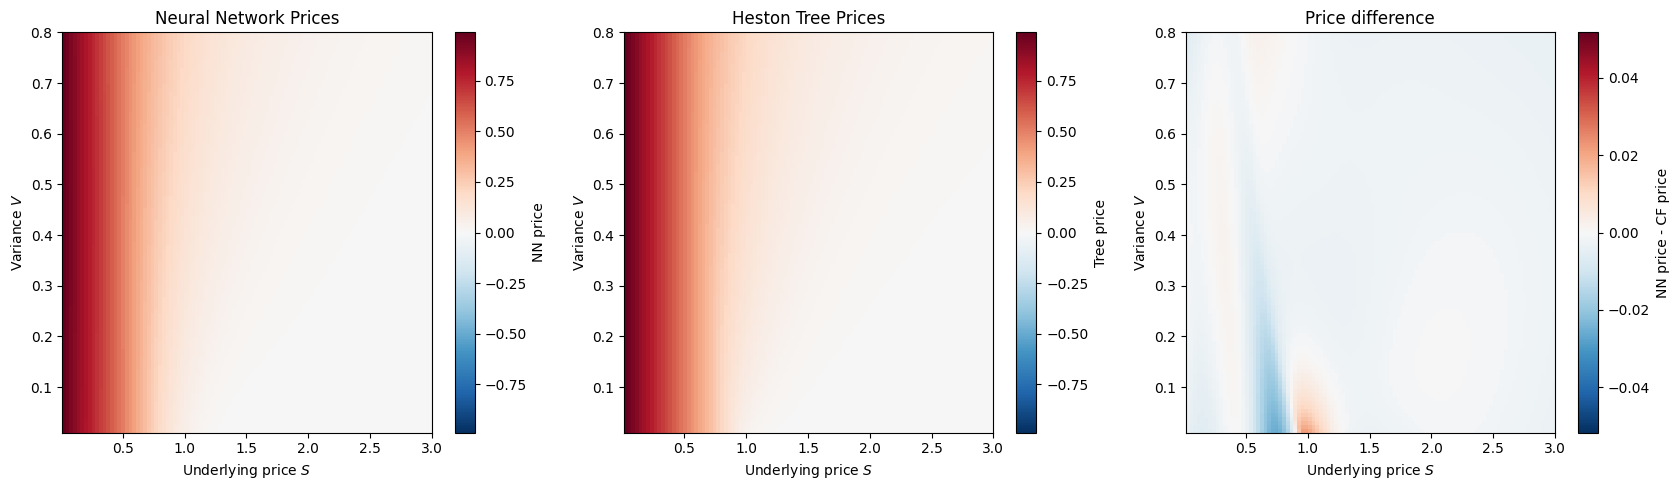

In [5]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price $S$')
plt.ylabel('Variance $V$')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(ht_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='Tree price')
plt.xlabel('Underlying price $S$')
plt.ylabel('Variance $V$')
plt.title('Heston Tree Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - ht_prices
vmax = np.abs(diff).max()*2
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price $S$')
plt.ylabel('Variance $V$')
plt.title('Price difference')
plt.tight_layout()

plt.savefig('../../plots/heston/heston_1d_comparison_heatmap.png')
plt.show()

### Line plots for varying $S$, varying $V$ and varying $t$

In [6]:
# Prepare term structure
ts = np.linspace(0, T-1e-4, resolution)
V = 0.1
S = 1.0

nn_prices_time_all = np.zeros((resolution, len(pinns)))
ht_prices_time = np.zeros(resolution)
for i, t_val in enumerate(ts):
    ht_prices_time[i] = tree.price(V, S, int(t_val * n - 0.5))

    for k, pinn in enumerate(pinns):
        nn_prices_time_all[i, k] = pinn.predict(t_val, S, V).item()

nn_prices_time = np.mean(nn_prices_time_all, axis=1)

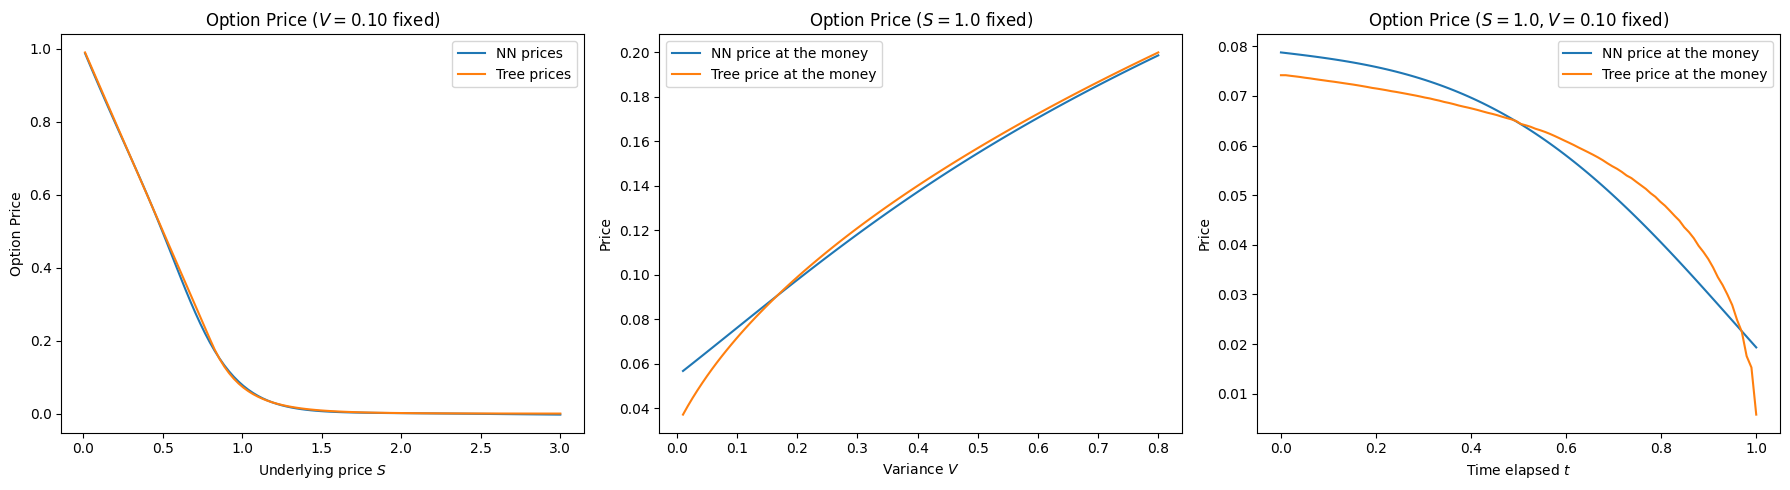

In [7]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
v_ind = 11
plt.plot(Ss, nn_prices[v_ind, :], label='NN prices')
plt.plot(Ss, ht_prices[v_ind, :], label='Tree prices')
plt.xlabel('Underlying price $S$')
plt.ylabel('Option Price')
plt.title(f'Option Price ($V={Vs[v_ind]:.2f}$ fixed)')
plt.legend()

plt.subplot(1, 3, 2)
S_ind = 33
plt.plot(Vs, nn_prices[:, S_ind], label='NN price at the money')
plt.plot(Vs, ht_prices[:, S_ind], label='Tree price at the money')
plt.xlabel('Variance $V$')
plt.ylabel('Price')
plt.title(f'Option Price ($S={Ss[S_ind]:.1f}$ fixed)')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(ts, nn_prices_time, label='NN price at the money')
plt.plot(ts, ht_prices_time, label='Tree price at the money')
plt.xlabel('Time elapsed $t$')
plt.ylabel('Price')
plt.legend()
plt.title(f'Option Price ($S={S:.1f}, V={V:.2f}$ fixed)')

plt.tight_layout()
plt.savefig('../../plots/heston/heston_1d_comparison_line.png')
plt.show()

In [8]:
ts = np.linspace(0, T-1e-4, resolution)
V = 0.1
S = 1.0

nn_prices_time_all = np.zeros((resolution, len(pinns)))
ht_prices_time = np.zeros(resolution)
for i, t_val in enumerate(ts):
    ht_prices_time[i] = tree.price(V, S, int(t_val * n - 0.5))

    for k, pinn in enumerate(pinns):
        nn_prices_time_all[i, k] = pinn.predict(t_val, S, V).item()

nn_prices_time = np.mean(nn_prices_time_all, axis=1)

### Numerical values

In [9]:
nn_prices_atm = [pinns[i].predict(0, S, V).item() for i in range(len(pinns))]
nn_price_atm = np.mean(nn_prices_atm)
nn_price_atm_std = np.std(nn_prices_atm)
standard_error = 1.96 * nn_price_atm_std / np.sqrt(len(pinns))

ht_price_atm = tree.price(V, S, 0)

print(f"NN price at the money: {nn_price_atm:.4f} ± {standard_error:.4f} (95% CI)")
print(f"Tree price at the money: {ht_price_atm:.4f}")

relative_error = np.abs(nn_price_atm - ht_price_atm) / np.abs(ht_price_atm)
print(f"Relative error: {relative_error:.2%}")

NN price at the money: 0.0788 ± 0.0030 (95% CI)
Tree price at the money: 0.0742
Relative error: 6.18%


## Continuation probabilities

In [10]:
Vs_free = np.linspace(0.01, V_max, resolution)
Ss_free = np.linspace(0.3, 1.0, resolution)
t = 0

intrinsics = np.tile(np.maximum(K - Ss_free, 0), (resolution, 1))

ht_continuation_values = np.zeros((resolution, resolution))
nn_continuation_values_all = np.zeros((resolution, resolution, len(pinns)))

for i, v_val in enumerate(Vs_free):
    for j, s_val in enumerate(Ss_free):
        ht_continuation_values[i, j] = tree.price(v_val, s_val, 0, continuation_value=True)

        for k, pinn in enumerate(pinns):
            nn_continuation_values_all[i, j, k] = estimate_contination_value_heston(pinn.model, t, s_val, v_val, r, kappa, theta, sigma, rho, n_paths=1000).item()

nn_continuation_values = np.mean(nn_continuation_values_all, axis=2)
nn_continuation_values_std = np.std(nn_continuation_values_all, axis=2)


/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:29: RuntimeWarning: divide by zero encountered in divide
  d = (continuation - intrinsics + shift) / intrinsics


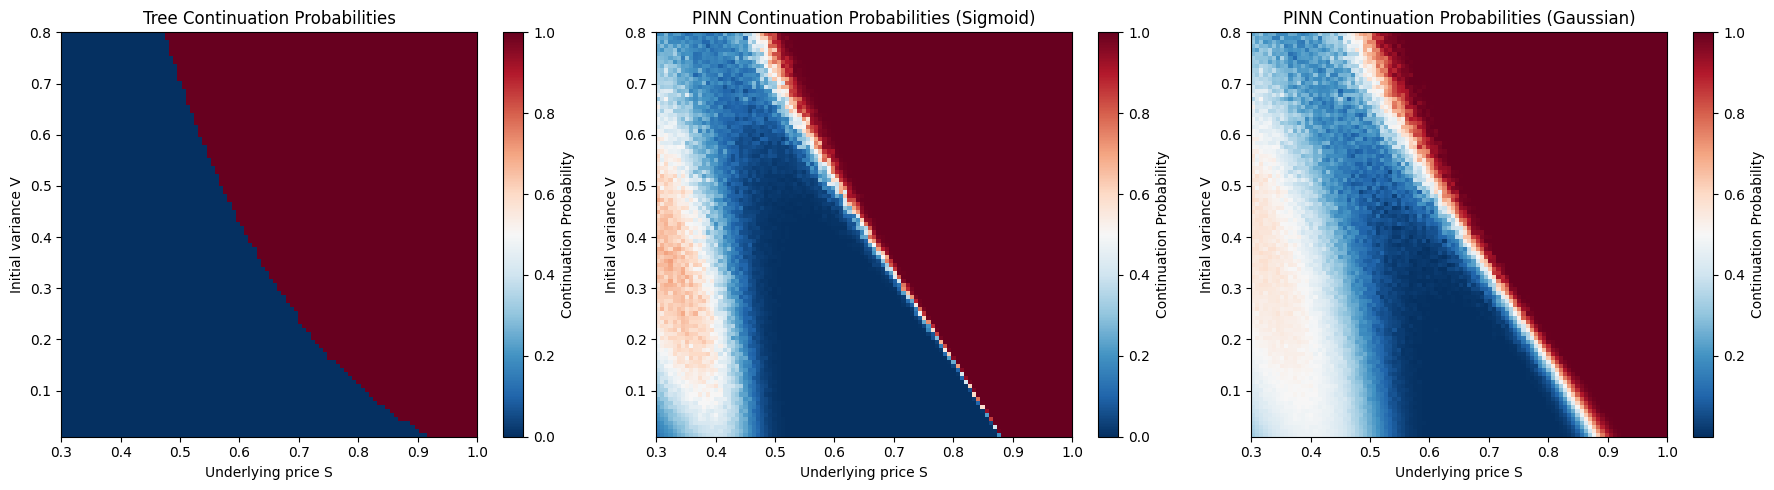

In [11]:

ht_continuation_probs = np.where(ht_continuation_values > intrinsics, 1.0, 0.0)
nn_continuation_probs_sigmoid = compute_continuation_probs(nn_continuation_values, intrinsics, eps=1e-2)
nn_continuation_probs_gaussian = continuation_normal(nn_continuation_values, nn_continuation_values_std, intrinsics)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(ht_continuation_probs, extent=[Ss_free[0], Ss_free[-1], Vs_free[0], Vs_free[-1]],
           aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance V')
plt.title('Tree Continuation Probabilities')

plt.subplot(1, 3, 2)
plt.imshow(nn_continuation_probs_sigmoid, extent=[Ss_free[0], Ss_free[-1], Vs_free[0], Vs_free[-1]],
           aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance V')
plt.title('PINN Continuation Probabilities (Sigmoid)')

plt.subplot(1, 3, 3)
plt.imshow(nn_continuation_probs_gaussian, extent=[Ss_free[0], Ss_free[-1], Vs_free[0], Vs_free[-1]],
           aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance V')
plt.title('PINN Continuation Probabilities (Gaussian)')

plt.tight_layout()
plt.savefig('../../plots/heston/heston_1d_continuation_probs.png')
plt.show()